#Ejercicio # 1_ Sistema con IA para clasificatoria de reciclaje

Entrenar un modelo con las clases:
* cardboard
* glass
* metal
* paper
* plastic
* trash

Al final guardara el modelo y las clases para usarlo en Streamlit.

# Paso 1. Instalar dependencias

In [25]:
!pip install tensorflow numpy pillow matplotlib

In [26]:
from kagglehub import dataset_download

dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")

print("Ruta del dataset:", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del dataset: /kaggle/input/garbage-classification-image-dataset


In [27]:
import os

for folder in os.listdir(dataset_path):
  print(folder)

dataset


In [28]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,

    image_size=(224,224),

    batch_size=32

)

class_names = train_ds.class_names

print(class_names)


Found 2972 files belonging to 1 classes.
['dataset']


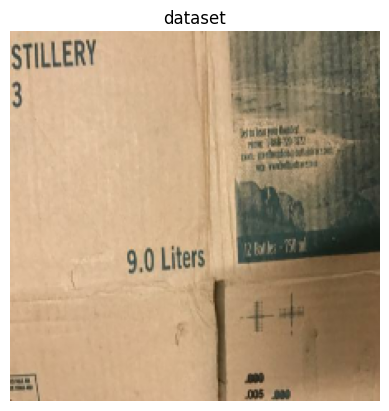

In [29]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.imshow(images[0].numpy().astype("uint8"))

    plt.title(class_names[labels[0]])

    plt.axis("off")

#Paso 2. Importar Librerias


In [30]:
import json


import os


from pathlib import Path


import matplotlib.pyplot as plt


import numpy as np


import tensorflow as tf


from PIL import Image

## Paso 3. Ajustar la ruta del dataset

La carpeta del dataser debe de verse asi:

garbage-classification/
cardboard/
glass/
metal/
paper/
plastic/
trash/

##Paso  4. Cargar Imagenes


In [31]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

# Define DATA_DIR el path de kagglehub download

DATA_DIR = os.path.join(dataset_path, 'dataset')



train_data_path = os.path.join(DATA_DIR, 'Training')

val_data_path = os.path.join(DATA_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

val_ds = tf.keras.utils.image_dataset_from_directory(

    val_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

class_names = train_ds.class_names

print("Clases detectadas:", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


#Paso 5. Ver algunas imagenes

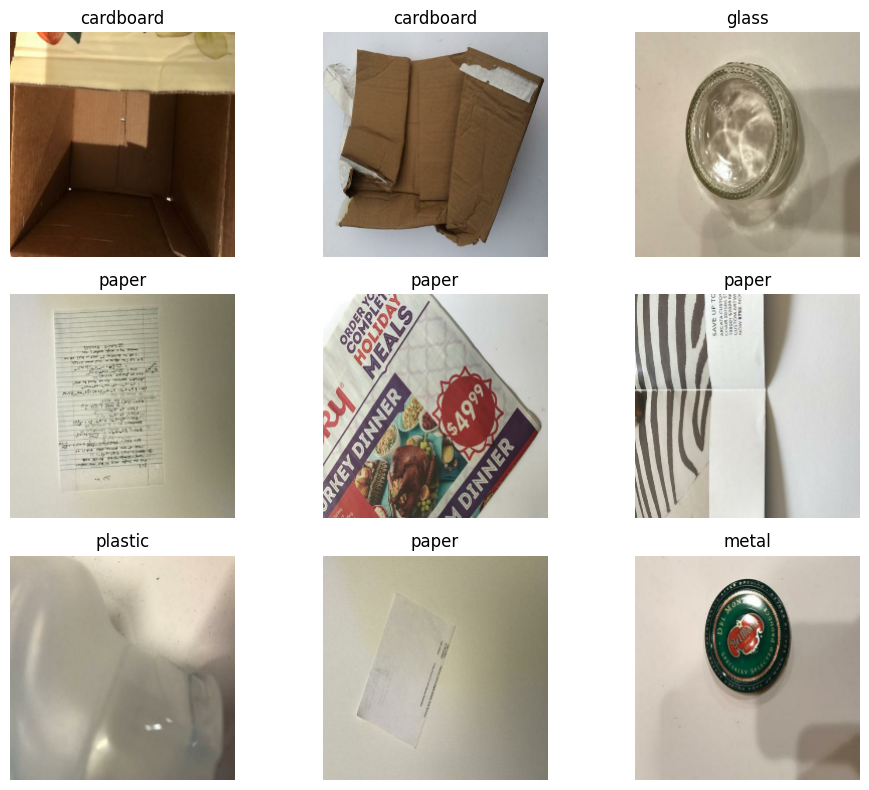

In [32]:
plt.figure(figsize=(10, 8))


for images, labels in train_ds.take(1):


    for i in range(min(9, len(images))):


        ax = plt.subplot(3, 3, i + 1)


        plt.imshow(images[i].numpy().astype("uint8"))


        plt.title(class_names[labels[i]])


        plt.axis("off")


plt.tight_layout()


plt.show()

#Paso 6. Preparar el dataset


In [33]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)



# Paso 7. Crear el modelo en base a MobileNetV2

In [34]:
#Crear el modelo MobileNetV


base_model = tf.keras.applications.MobileNetV2(


    input_shape=IMG_SIZE + (3,),


    include_top=False,


    weights="imagenet"

)


base_model.trainable = False


inputs = tf.keras.Input(shape=IMG_SIZE + (3,))


x = base_model(inputs, training=False)


x = tf.keras.layers.GlobalAveragePooling2D()(x)


x = tf.keras.layers.Dropout(0.2)(x)


outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)


model = tf.keras.Model(inputs, outputs)


model.compile(


    optimizer="adam",


    loss="sparse_categorical_crossentropy",


    metrics=["accuracy"]

)


model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Paso 8. Repasar una vez EPOCH = 1


In [35]:
EPOCHS = 1


callbacks = [


    tf.keras.callbacks.EarlyStopping(


        monitor="val_loss",


        patience=2,


        restore_best_weights=True


    )


]

history = model.fit(


    train_ds,


    validation_data=val_ds,


    epochs=EPOCHS,


    callbacks=callbacks,
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6025 - loss: 1.0701 - val_accuracy: 0.7263 - val_loss: 0.7423


#Paso 9. Evaluar

In [36]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"accuracy: {acc:.4f}")

Loss: 0.7423
accuracy: 0.7263


#Paso 10. Guardar el modelo


In [38]:
OUTPUT_DIR = Path("modelo_reciclaje_mobilenet")

OUTPUT_DIR.mkdir(exist_ok=True)

model.save(OUTPUT_DIR / "waste_mobilenet.h5")

#(HDF5- Hierarchical Data Format version 5)

model.save(OUTPUT_DIR / "waste_mobilenet.keras")

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:

    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.h5")

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.keras")

print("Clases guardadas en:", OUTPUT_DIR / "class_names.json")



Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.h5
Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.keras
Clases guardadas en: modelo_reciclaje_mobilenet/class_names.json


Plástico: 79.90%
Papel: 9.35%
Basura: 5.03%


(np.float64(-0.5), np.float64(511.5), np.float64(334.5), np.float64(-0.5))

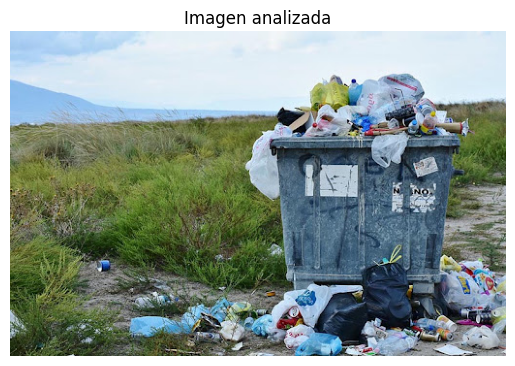

In [40]:
LABELS_ES = {

    "cardboard": "Cartón",

    "glass": "Vidrio",

    "metal": "Metal",

    "paper": "Papel",

    "plastic": "Plástico",

    "trash": "Basura",

}



def predict_image(img_path_param):

    img = Image.open(img_path_param).convert("RGB").resize(IMG_SIZE)

    arr = np.array(img, dtype=np.float32) / 255.0

    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]

    top3_idx = np.argsort(preds)[-3:][::-1]

    for idx in top3_idx:

        raw = class_names[idx]

        print(f"{LABELS_ES.get(raw, raw)}: {preds[idx]*100:.2f}%")

    return class_names[np.argmax(preds)]

# Ejemplo:

example_img_path = "Basura.jpg"

predict_image(example_img_path)

plt.imshow(Image.open(example_img_path)); plt.title("Imagen analizada"); plt.axis("off")

